# **MÓDULO 20 - Projeto de Credit Score - Naive Bayes**


No módulo 17 vocês realizaram a primeira etapa do projeto de crédito de vocês.
Então fizeram o tratamendo dos dados, balancearam as classes, transformaram as variáveis categóricas e separam base de treino e teste.
Nessa aula aplicaremos o algoritmo de naive bayes a base de vocês afim de tentarmos trazer previsões do score de crédito.

**IMPORTANTE:** Não se esqueçam de ao enviar o código de vocês para os tutores, enviarem as bases, pois como cada um de vocês realizou as alterações de tratamento indidualmente o tutor precisa ter acesso aos seus dados individuais.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
from sklearn.metrics import recall_score

Durante a aula nossa variável a ser prevista (churn) continha apenas 2 categorias, a base de vocês contém mais. O Naive Bayes pode ser aplicado para problemas de classificação com múltiplas classes da mesma forma que para problemas de classificação binária. O Naive Bayes é um algoritmo de classificação probabilístico que calcula a probabilidade de uma amostra pertencer a cada classe e seleciona a classe com a maior probabilidade como a previsão final.
Em resumo, o Naive Bayes pode ser aplicado da mesma maneira para problemas de classificação com múltiplas classes, e os mesmos princípios se aplicam em termos de treinamento, avaliação e aplicação do modelo.

# 1) Comece carregando as bases de treino (X e y) e teste (X e y).
Verifique se o número de linhas condiz, se as variáveis estão corretas sendo apenas a de score para y e as demais nas bases de X e por último, se Y está balanceada no teste.

In [2]:
X_treino = pd.read_csv('X_treino.csv')
y_treino = pd.read_csv('y_treino.csv')['Credit Score']
X_teste = pd.read_csv('X_teste.csv')
y_teste = pd.read_csv('y_teste.csv')['Credit Score']

# No Módulo 17 o Credit Score foi codificado com LabelEncoder (ordem alfabética)
nomes_classes = {0: 'Average', 1: 'High', 2: 'Low'}

# 1) Número de linhas: X e y de cada base precisam ter o mesmo tamanho
print(f'Treino -> X: {X_treino.shape} | y: {y_treino.shape}')
print(f'Teste  -> X: {X_teste.shape} | y: {y_teste.shape}')
print()

# 2) Variáveis: y só com o score, X com as demais (sem vazamento do alvo)
print('Colunas de X:', list(X_treino.columns))
print('Colunas iguais em treino e teste:', list(X_treino.columns) == list(X_teste.columns))
print('Credit Score dentro de X?', 'Credit Score' in X_treino.columns)
print()

# 3) Balanceamento
print('Distribuição de y_treino:')
print(y_treino.map(nomes_classes).value_counts())
print()
print('Distribuição de y_teste:')
print(y_teste.map(nomes_classes).value_counts(normalize=True).round(3))

Treino -> X: (270, 10) | y: (270,)
Teste  -> X: (33, 10) | y: (33,)

Colunas de X: ['Age', 'Income', 'Number of Children', 'Gender_Male', "Education_Bachelor's Degree", 'Education_Doctorate', 'Education_High School Diploma', "Education_Master's Degree", 'Marital Status_Single', 'Home Ownership_Rented']
Colunas iguais em treino e teste: True
Credit Score dentro de X? False

Distribuição de y_treino:
Credit Score
High       90
Low        90
Average    90
Name: count, dtype: int64

Distribuição de y_teste:
Credit Score
High       0.697
Average    0.212
Low        0.091
Name: proportion, dtype: float64


**Verificação das bases:**

**Linhas:** o treino tem 270 registros em X e em y, e o teste tem 33 em X e em y. Os tamanhos batem dentro de cada base. O treino tem 270 linhas (e não as 131 da separação original) porque é a base balanceada com SMOTE no Módulo 17.

**Variáveis:** X tem 10 colunas, as 3 numéricas (Age, Income, Number of Children) e as 7 criadas pelo One Hot Encoding (gênero, escolaridade, estado civil e moradia). As colunas são iguais em treino e teste, e `Credit Score` não está em X, então não há vazamento do alvo. Y contém apenas o score, codificado como 0 = Average, 1 = High e 2 = Low.

**Balanceamento:** `y_treino` está balanceado, com 90 clientes em cada classe. Já `y_teste` **não** está balanceado, e isso é o correto: como definido no Módulo 17, o SMOTE foi aplicado apenas no treino, e o teste mantém a proporção real da base (cerca de 70% High, 21% Average e 9% Low). Balancear o teste colocaria clientes sintéticos na avaliação e mediria o modelo num cenário que não existe no mundo real.

# 2) Aplique o algoritmo de Naive Bayes aos dados de treinamento.

In [3]:
modelo = GaussianNB()
modelo.fit(X_treino, y_treino)

print('Classes aprendidas:', [nomes_classes[c] for c in modelo.classes_])
print('Probabilidades a priori:', modelo.class_prior_.round(3))

Classes aprendidas: ['Average', 'High', 'Low']
Probabilidades a priori: [0.333 0.333 0.333]


Usei o **GaussianNB** porque todas as variáveis de X são numéricas (idade e renda contínuas, filhos como contagem e as colunas do One Hot como 0 e 1). Como o treino foi balanceado, as probabilidades a priori aprendidas são iguais para as três classes (1/3 cada), então o modelo decide só pela evidência das variáveis, sem favorecer a classe High, que domina a base original.

# 3) Faça a avaliação do modelo com os dados de treinamento.
Traga a acurácia, recall e plote a matriz de confusão. Não se esqueça de avaliar com suas palavras o desempenho do modelo, interpretando as métricas.

Dica: Para calcularmos o recall em classificação multi classe precisamos usar o atributo macro:
recall = recall_score(y_train, y_pred_train, average='macro')

Acurácia (treino): 0.9963
Recall macro (treino): 0.9963


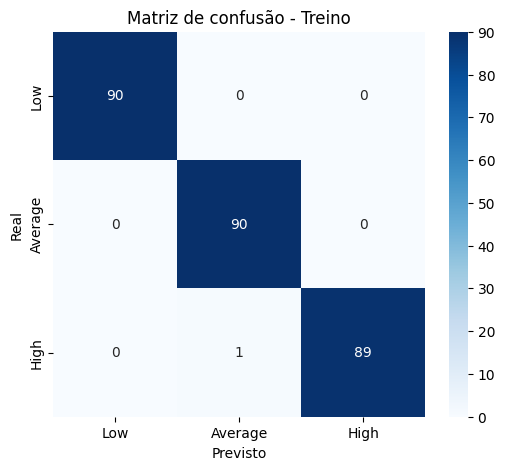

In [4]:
y_pred_treino = modelo.predict(X_treino)

acuracia_treino = accuracy_score(y_treino, y_pred_treino)
recall_treino = recall_score(y_treino, y_pred_treino, average='macro')
print(f'Acurácia (treino): {acuracia_treino:.4f}')
print(f'Recall macro (treino): {recall_treino:.4f}')

# Ordem das classes na matriz: Low, Average, High (do maior para o menor risco)
ordem = [2, 0, 1]
rotulos = [nomes_classes[c] for c in ordem]

cm_treino = confusion_matrix(y_treino, y_pred_treino, labels=ordem)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_treino, annot=True, fmt='d', cmap='Blues', xticklabels=rotulos, yticklabels=rotulos)
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.title('Matriz de confusão - Treino')
plt.show()

**Avaliação no treino:** acurácia de **99,6%** e recall macro de **99,6%**. Das 270 previsões, apenas 1 errou: um cliente High classificado como Average. Todos os clientes Low e Average foram classificados corretamente.

**Leitura das métricas:** a acurácia mede o percentual total de acertos, e o recall macro calcula o recall de cada classe separadamente e tira a média simples, dando o mesmo peso às três. Como o treino está balanceado, as duas métricas praticamente coincidem. A diagonal da matriz concentra quase tudo, e o único erro acontece entre High e Average, os perfis mais parecidos entre si.

Um desempenho tão alto no treino, sozinho, não prova que o modelo é bom, porque ele está sendo avaliado nos mesmos dados em que aprendeu (e parte deles são clientes sintéticos criados pelo SMOTE). A prova real é o teste, na próxima etapa.

# 4) Aplique o modelo aos dados de teste e realize a avaliação dos resultados, da mesma forma que fez acima. Não se esqueça de avaliar com as suas palavras e comparar o desempenho da base treino com a teste.

Acurácia (teste): 1.0000
Recall macro (teste): 1.0000


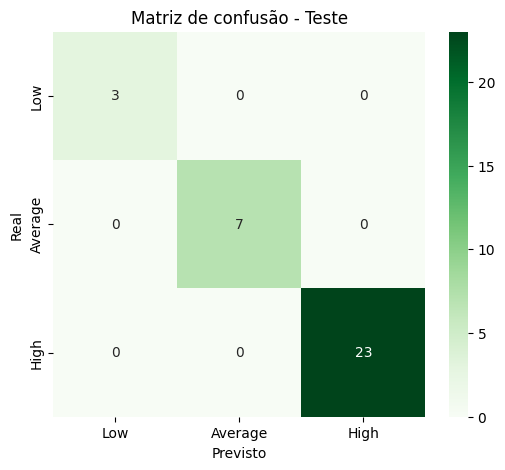

              Treino  Teste
Acurácia      0.9963    1.0
Recall macro  0.9963    1.0


In [5]:
y_pred_teste = modelo.predict(X_teste)

acuracia_teste = accuracy_score(y_teste, y_pred_teste)
recall_teste = recall_score(y_teste, y_pred_teste, average='macro')
print(f'Acurácia (teste): {acuracia_teste:.4f}')
print(f'Recall macro (teste): {recall_teste:.4f}')

cm_teste = confusion_matrix(y_teste, y_pred_teste, labels=ordem)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_teste, annot=True, fmt='d', cmap='Greens', xticklabels=rotulos, yticklabels=rotulos)
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.title('Matriz de confusão - Teste')
plt.show()

print(pd.DataFrame({'Treino': [acuracia_treino, recall_treino], 'Teste': [acuracia_teste, recall_teste]},
                   index=['Acurácia', 'Recall macro']).round(4))

In [6]:
# Investigação crítica: quantos clientes do teste têm um perfil idêntico a algum cliente do treino?
iguais = X_teste.merge(X_treino.drop_duplicates(), how='inner', on=list(X_teste.columns))
print(f'Clientes do teste com perfil idêntico no treino: {len(iguais)} de {len(X_teste)}')

# Separação quase perfeita pela moradia ajuda a explicar a facilidade do problema
print(pd.crosstab(X_teste['Home Ownership_Rented'], y_teste.map(nomes_classes)))

Clientes do teste com perfil idêntico no treino: 10 de 33
Credit Score           Average  High  Low
Home Ownership_Rented                    
0                            1    23    0
1                            6     0    3


**Avaliação no teste:** acurácia de **100%** e recall macro de **100%**. Todos os 33 clientes foram classificados corretamente, incluindo os 3 clientes Low, a classe mais rara e a mais importante para o negócio (são os de maior risco de crédito).

**Comparação treino x teste:** o desempenho no teste ficou igual ou até levemente superior ao do treino, então **não há sinal de overfitting**: o modelo não decorou o treino, ele generaliza para clientes que não viu.

**Senso crítico sobre um resultado perfeito:** 100% em dados reais é raro e merece investigação antes de comemorar. Encontrei três explicações:

**Problema muito separável:** a moradia quase define sozinha a classe. No teste, os 23 clientes High moram em casa própria, e todos os 3 clientes Low moram de aluguel. Com sinais tão fortes (somados a estado civil e escolaridade, já vistos na análise bivariada do Módulo 17), qualquer classificador acerta com facilidade.

**Perfis repetidos:** 10 dos 33 clientes do teste têm um perfil idêntico a algum cliente do treino, porque a base original tem 45 linhas duplicadas que não foram removidas. Para esses clientes, o modelo já tinha visto a resposta, o que deixa a métrica de teste mais otimista do que seria com clientes totalmente novos. Mesmo assim, os outros 23 clientes, que o modelo nunca viu, também foram todos acertados.

**Teste pequeno:** com só 33 clientes (e apenas 3 Low), cada erro mudaria a acurácia em cerca de 3 pontos. O resultado é promissor, mas uma base maior daria uma estimativa mais confiável do desempenho real.

# 5) Descreva com suas palavras o projeto desenvolvido nessa atividade e qual o nosso objetivo principal ao aplicarmos o algoritmo de naive bayes a base de crédito.
Utilize pelo menos 4 linhas.

Dica: Caso você ainda esteja tendo dificuldade em visualizar a aplicação dos projetos e objetivo, consulte seus tutores!

**Resposta:**

Este projeto simula o trabalho de uma área de crédito que precisa classificar o risco de cada cliente antes de conceder crédito. Partindo da base tratada no Módulo 17 (renda convertida para número, idades faltantes preenchidas com a mediana, variáveis categóricas transformadas com One Hot Encoding, treino e teste separados e classes balanceadas com SMOTE apenas no treino), aplicamos o Naive Bayes para prever o **Credit Score** de cada cliente nas categorias Low, Average e High.

O objetivo principal é usar características conhecidas do cliente, como renda, idade, escolaridade, estado civil e tipo de moradia, para estimar a sua classe de score de forma automática, rápida e padronizada. O Naive Bayes faz isso calculando, com base no Teorema de Bayes, a probabilidade de o cliente pertencer a cada classe e escolhendo a mais provável.

Para o negócio, o valor está em identificar principalmente os clientes de score **Low**, que representam maior risco de inadimplência. Por isso acompanhamos o **recall macro**: ele garante que o modelo acerte bem todas as classes, inclusive a minoritária, e não apenas a classe High, que domina a base.

O modelo teve desempenho excelente em treino e teste, sem sinais de overfitting. Como a base é pequena e contém perfis repetidos, o próximo passo seria validar o modelo com mais clientes e compará-lo com outros algoritmos, como a Árvore de Decisão do Módulo 21, antes de usá-lo em decisões reais de crédito.